# Diagnostic Power Analysis

- `KAN`: for `alpha > 0`, rejection probabilities can be read as finite-sample power against nonadditive misspecification.
- `CausalNSF`: the same curves are shown for comparison and should be read as diagnostic rejection probabilities.
- `Oracle SCM`: lower-bound reference obtained from fresh samples of the true DGP and the true exogenous variables.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tueplots import bundles

from utils.diagnostics import wilson_interval
from utils.paths import get_experiment_paths

paths = get_experiment_paths("diagnostic_power")
df = pd.read_csv(paths.data / "diagnostic_power_results.csv")
df.head()

,dataset,alpha,n,seed,model_name,data_seed,fit_seed,sample_seed,validation_size,pvalue_alpha,...,calibrated_c2st_threshold,calibrated_c2st_n_null,reject_calibrated_c2st,holm_calibrated_hsic3_pvalue,holm_calibrated_dhsic_pvalue,holm_calibrated_c2st_pvalue,holm_reject_calibrated_hsic3,holm_reject_calibrated_dhsic,holm_reject_calibrated_c2st,reject_calibrated_global
0,triangle-sensitivity-nonlinear,0.0,10,0,flow,0,23,2023,10,0.05,...,0.8,99,1,0.90,0.58,0.09,0,0,0,0
1,triangle-sensitivity-nonlinear,0.0,10,0,kan,0,11,1011,10,0.05,...,0.8,99,0,0.48,0.60,0.60,0,0,0,0
2,triangle-sensitivity-nonlinear,0.0,10,0,oracle,0,0,500000,10,0.05,...,0.8,99,0,1.00,1.00,1.00,0,0,0,0
3,triangle-sensitivity-nonlinear,0.0,10,1,flow,1,24,2024,10,0.05,...,0.8,99,0,0.16,0.03,0.93,0,1,0,1
4,triangle-sensitivity-nonlinear,0.0,10,1,kan,1,12,1012,10,0.05,...,0.8,99,0,1.00,1.00,1.00,0,0,0,0


In [3]:
diagnostic_map = {
    "reject_hsic3": "HSIC x3",
    "reject_dhsic": "dHSIC",
    "reject_c2st": "C2ST",
    "reject_global": "Global Holm-OR",
}
raw_metric_map = {
    "hsic_x3_stat": "HSIC x3 stat.",
    "dhsic_stat": "dHSIC stat.",
    "c2st_accuracy": "RF acc. obs.",
    "ate_error": "ATE error",
    "cf_mae": "CF MAE",
}
alpha_label_map = {
    0.0: r"$\alpha = 0$",
    0.5: r"$\alpha = 0.5$",
    1.0: r"$\alpha = 1.0$",
}
model_label_map = {
    "kan": "KAN",
    "flow": "CausalNSF",
    "oracle": "Oracle SCM",
}
model_order = ["KAN", "CausalNSF", "Oracle SCM"]
diagnostic_order = ["HSIC x3", "dHSIC", "C2ST", "Global Holm-OR"]
raw_metric_order = ["HSIC x3 stat.", "dHSIC stat.", "RF acc. obs.", "ATE error", "CF MAE"]
alpha_order = [0.0, 0.5, 1.0]
line_style_map = {0.0: "-", 0.5: "--", 1.0: ":"}
marker_map = {0.0: "o", 0.5: "s", 1.0: "^"}
palette = {0.0: "#1f77b4", 0.5: "#ff7f0e", 1.0: "#2ca02c"}
oracle_color = "#7f7f7f"
n_ticks = sorted(df["n"].unique())

reject_long = df.melt(
    id_vars=["model_name", "alpha", "n", "seed"],
    value_vars=list(diagnostic_map.keys()),
    var_name="diagnostic_key",
    value_name="reject",
)
reject_long["diagnostic"] = reject_long["diagnostic_key"].map(diagnostic_map)
reject_long["model_label"] = reject_long["model_name"].map(model_label_map)

reject_rows = []
for (model_name, model_label, alpha_value, n_value, diagnostic), group in reject_long.groupby(
    ["model_name", "model_label", "alpha", "n", "diagnostic"], dropna=False
):
    successes = int(group["reject"].sum())
    total = int(group["reject"].count())
    wilson_low, wilson_high = wilson_interval(successes, total)
    reject_rows.append(
        {
            "model_name": model_name,
            "model_label": model_label,
            "alpha": float(alpha_value),
            "alpha_label": alpha_label_map[float(alpha_value)],
            "n": int(n_value),
            "diagnostic": diagnostic,
            "num_runs": total,
            "rejection_probability": successes / total,
            "wilson_low": wilson_low,
            "wilson_high": wilson_high,
        }
    )

reject_summary_df = pd.DataFrame(reject_rows).sort_values(["model_name", "diagnostic", "alpha", "n"]).reset_index(drop=True)
reject_summary_df.to_csv(paths.data / "diagnostic_power_rejection_summary.csv", index=False)

raw_long = df.melt(
    id_vars=["model_name", "alpha", "n", "seed"],
    value_vars=list(raw_metric_map.keys()),
    var_name="metric_key",
    value_name="value",
)
raw_long["metric"] = raw_long["metric_key"].map(raw_metric_map)
raw_long["model_label"] = raw_long["model_name"].map(model_label_map)

raw_rows = []
for (model_name, model_label, alpha_value, n_value, metric), group in raw_long.groupby(
    ["model_name", "model_label", "alpha", "n", "metric"], dropna=False
):
    mean_value = float(group["value"].mean())
    std_value = float(group["value"].std(ddof=1)) if len(group) > 1 else 0.0
    sem = std_value / np.sqrt(len(group)) if len(group) > 0 else np.nan
    ci_half_width = 1.96 * sem if np.isfinite(sem) else np.nan
    raw_rows.append(
        {
            "model_name": model_name,
            "model_label": model_label,
            "alpha": float(alpha_value),
            "alpha_label": alpha_label_map[float(alpha_value)],
            "n": int(n_value),
            "metric": metric,
            "mean": mean_value,
            "ci_low": mean_value - ci_half_width if np.isfinite(ci_half_width) else np.nan,
            "ci_high": mean_value + ci_half_width if np.isfinite(ci_half_width) else np.nan,
        }
    )

raw_summary_df = pd.DataFrame(raw_rows).sort_values(["model_name", "metric", "alpha", "n"]).reset_index(drop=True)
raw_summary_df.to_csv(paths.data / "diagnostic_power_raw_summary.csv", index=False)

reject_summary_df.head()

,model_name,model_label,alpha,alpha_label,n,diagnostic,num_runs,rejection_probability,wilson_low,wilson_high
0,flow,CausalNSF,0.0,$\alpha = 0$,10,C2ST,100,0.03,0.010255,0.084519
1,flow,CausalNSF,0.0,$\alpha = 0$,50,C2ST,100,0.12,0.069994,0.198121
2,flow,CausalNSF,0.0,$\alpha = 0$,100,C2ST,100,0.22,0.150013,0.310704
3,flow,CausalNSF,0.0,$\alpha = 0$,500,C2ST,100,0.16,0.100953,0.244203
4,flow,CausalNSF,0.0,$\alpha = 0$,1000,C2ST,100,0.19,0.125148,0.277788


In [4]:
def first_n_at_threshold(group, column_name, threshold=0.8):
    eligible = group.loc[group[column_name] >= threshold].sort_values("n")
    if eligible.empty:
        return f">{int(group['n'].max())}"
    return int(eligible.iloc[0]["n"])


n80_rows = []
for (model_name, model_label, diagnostic, alpha_value), group in reject_summary_df.loc[reject_summary_df["alpha"] > 0].groupby(
    ["model_name", "model_label", "diagnostic", "alpha"], dropna=False
):
    group = group.sort_values("n")
    n80_rows.append(
        {
            "model_name": model_name,
            "model_label": model_label,
            "diagnostic": diagnostic,
            "alpha": float(alpha_value),
            "N_80": first_n_at_threshold(group, "rejection_probability", threshold=0.8),
            "N_80_LCB": first_n_at_threshold(group, "wilson_low", threshold=0.8),
        }
    )

n80_df = pd.DataFrame(n80_rows).sort_values(["model_name", "diagnostic", "alpha"]).reset_index(drop=True)
n80_df.to_csv(paths.data / "diagnostic_power_n80_summary.csv", index=False)
n80_df

,model_name,model_label,diagnostic,alpha,N_80,N_80_LCB
0,flow,CausalNSF,C2ST,0.5,>6000,>6000
1,flow,CausalNSF,C2ST,1.0,>6000,>6000
2,flow,CausalNSF,Global Holm-OR,0.5,1000,>6000
3,flow,CausalNSF,Global Holm-OR,1.0,500,500
4,flow,CausalNSF,HSIC x3,0.5,>6000,>6000
5,flow,CausalNSF,HSIC x3,1.0,6000,>6000
6,flow,CausalNSF,dHSIC,0.5,1000,>6000
7,flow,CausalNSF,dHSIC,1.0,500,500
8,kan,KAN,C2ST,0.5,6000,6000
9,kan,KAN,C2ST,1.0,1000,3000


C:\Users\Alex\AppData\Local\Temp\ipykernel_36932\2250451028.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


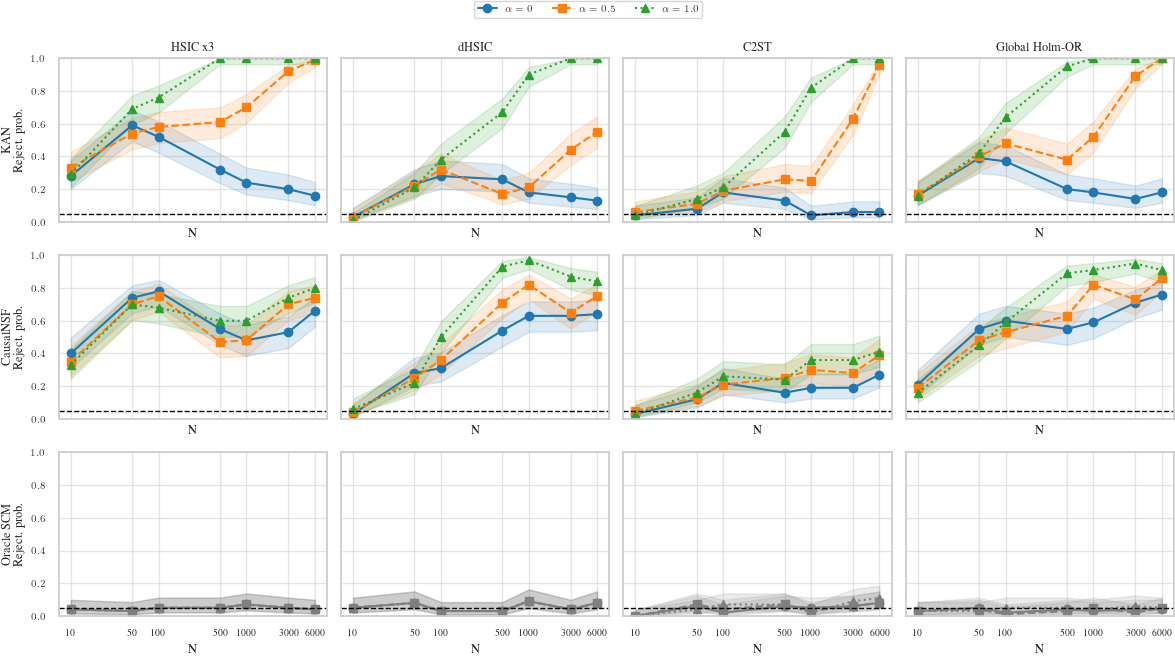

In [5]:
sns.set_theme(style="whitegrid")

with plt.rc_context({**bundles.neurips2024(nrows=3, ncols=4)}):
    fig, axes = plt.subplots(3, 4, figsize=(12, 6.4), sharex=True, sharey=True)
    for row_index, model_label in enumerate(model_order):
        for col_index, diagnostic in enumerate(diagnostic_order):
            ax = axes[row_index, col_index]
            subset = reject_summary_df[
                (reject_summary_df["model_label"] == model_label)
                & (reject_summary_df["diagnostic"] == diagnostic)
            ]
            for alpha_value in alpha_order:
                alpha_subset = subset[subset["alpha"] == alpha_value].sort_values("n")
                if alpha_subset.empty:
                    continue
                color = oracle_color if model_label == "Oracle SCM" else palette[alpha_value]
                ax.plot(
                    alpha_subset["n"],
                    alpha_subset["rejection_probability"],
                    marker=marker_map[alpha_value],
                    linestyle=line_style_map[alpha_value],
                    color=color,
                    label=alpha_label_map[alpha_value],
                )
                ax.fill_between(
                    alpha_subset["n"],
                    alpha_subset["wilson_low"],
                    alpha_subset["wilson_high"],
                    color=color,
                    alpha=0.15,
                )

            ax.axhline(0.05, color="black", linestyle="--", linewidth=1)
            ax.set_xscale("log")
            ax.set_xticks(n_ticks)
            ax.set_xticklabels([str(value) for value in n_ticks])
            ax.set_ylim(0.0, 1.0)
            ax.set_xlabel("N")
            if row_index == 0:
                ax.set_title(diagnostic)
            if col_index == 0:
                ylabel = "Reject. prob."
                ax.set_ylabel(f"{model_label}\n{ylabel}")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    for axis in axes.flat:
        legend = axis.get_legend()
        if legend is not None:
            legend.remove()

    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=True)
    plt.tight_layout()
    plt.savefig(paths.figures / "diagnostic_power_rejection_probability.pdf", dpi=300, bbox_inches="tight")
    plt.savefig(paths.figures / "diagnostic_power_rejection_probability.png", dpi=300, bbox_inches="tight")
    plt.show()

C:\Users\Alex\AppData\Local\Temp\ipykernel_36932\1550027602.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


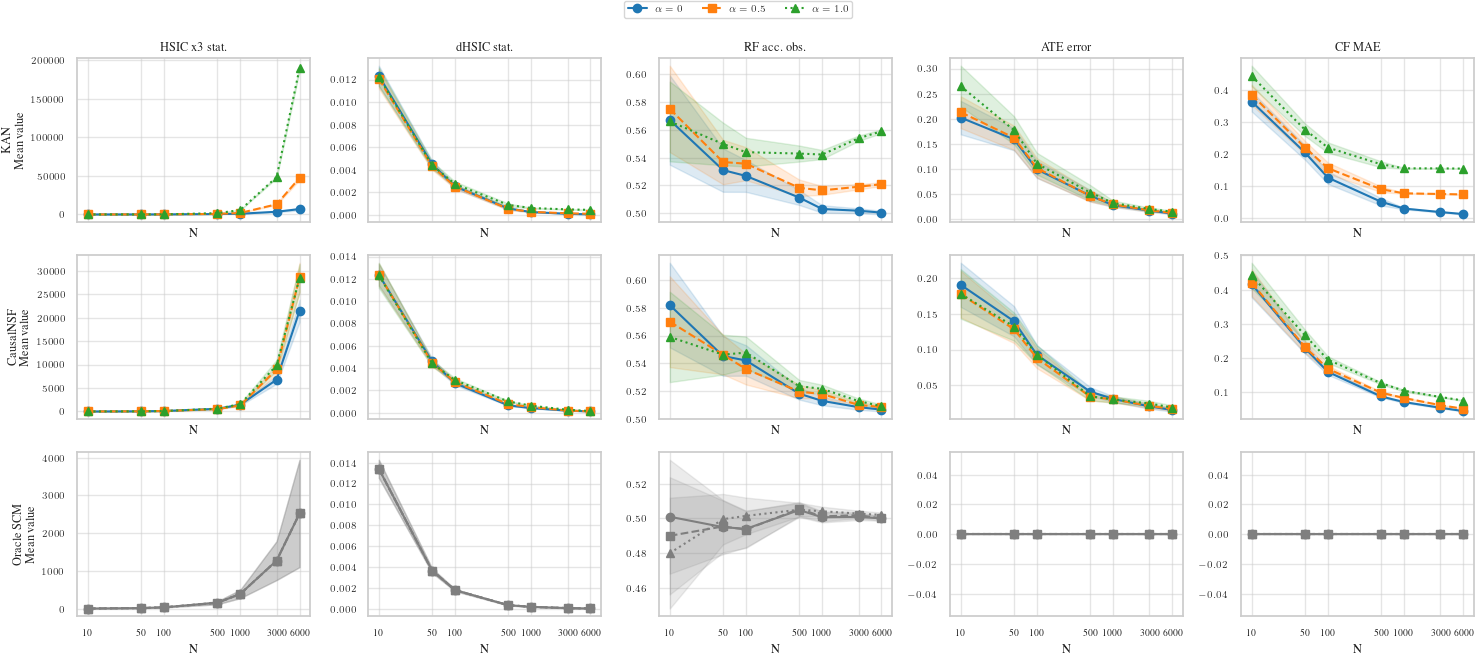

In [6]:
with plt.rc_context({**bundles.neurips2024(nrows=3, ncols=5)}):
    fig, axes = plt.subplots(3, 5, figsize=(15, 6.4), sharex=True)
    for row_index, model_label in enumerate(model_order):
        for col_index, metric in enumerate(raw_metric_order):
            ax = axes[row_index, col_index]
            subset = raw_summary_df[
                (raw_summary_df["model_label"] == model_label)
                & (raw_summary_df["metric"] == metric)
            ]
            for alpha_value in alpha_order:
                alpha_subset = subset[subset["alpha"] == alpha_value].sort_values("n")
                if alpha_subset.empty:
                    continue
                color = oracle_color if model_label == "Oracle SCM" else palette[alpha_value]
                ax.plot(
                    alpha_subset["n"],
                    alpha_subset["mean"],
                    marker=marker_map[alpha_value],
                    linestyle=line_style_map[alpha_value],
                    color=color,
                    label=alpha_label_map[alpha_value],
                )
                ax.fill_between(
                    alpha_subset["n"],
                    alpha_subset["ci_low"],
                    alpha_subset["ci_high"],
                    color=color,
                    alpha=0.15,
                )

            ax.set_xscale("log")
            ax.set_xticks(n_ticks)
            ax.set_xticklabels([str(value) for value in n_ticks])
            ax.set_xlabel("N")
            if row_index == 0:
                ax.set_title(metric)
            if col_index == 0:
                ax.set_ylabel(f"{model_label}\n Mean value")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    for axis in axes.flat:
        legend = axis.get_legend()
        if legend is not None:
            legend.remove()

    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=True)
    plt.tight_layout()
    plt.savefig(paths.figures / "diagnostic_power_raw_statistics.pdf", dpi=300, bbox_inches="tight")
    plt.savefig(paths.figures / "diagnostic_power_raw_statistics.png", dpi=300, bbox_inches="tight")
    plt.show()

C:\Users\Alex\AppData\Local\Temp\ipykernel_36932\500467870.py:111: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


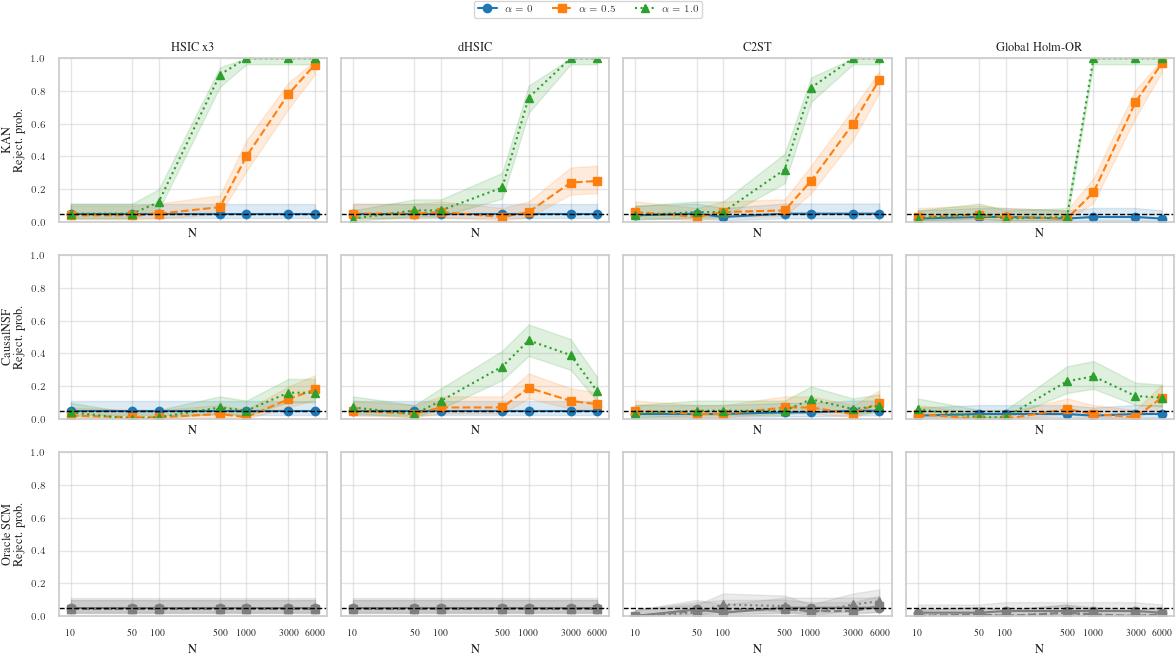

In [7]:
calibrated_diagnostic_map = {
    "reject_calibrated_hsic3": "HSIC x3",
    "reject_calibrated_dhsic": "dHSIC",
    "reject_calibrated_c2st": "C2ST",
    "reject_calibrated_global": "Global Holm-OR",
}

missing_cols = [col for col in calibrated_diagnostic_map if col not in df.columns]
if missing_cols:
    raise ValueError(
        "Missing calibrated rejection columns in diagnostic_power_results.csv: "
        f"{missing_cols}. Re-run the runnable after adding calibrated diagnostics."
    )

calibrated_reject_long = df.melt(
    id_vars=["model_name", "alpha", "n", "seed"],
    value_vars=list(calibrated_diagnostic_map.keys()),
    var_name="diagnostic_key",
    value_name="reject",
)
calibrated_reject_long["diagnostic"] = calibrated_reject_long["diagnostic_key"].map(calibrated_diagnostic_map)
calibrated_reject_long["model_label"] = calibrated_reject_long["model_name"].map(model_label_map)

calibrated_rows = []
for (model_name, model_label, alpha_value, n_value, diagnostic), group in calibrated_reject_long.groupby(
    ["model_name", "model_label", "alpha", "n", "diagnostic"], dropna=False
):
    successes = int(group["reject"].sum())
    total = int(group["reject"].count())
    wilson_low, wilson_high = wilson_interval(successes, total)
    calibrated_rows.append(
        {
            "model_name": model_name,
            "model_label": model_label,
            "alpha": float(alpha_value),
            "alpha_label": alpha_label_map[float(alpha_value)],
            "n": int(n_value),
            "diagnostic": diagnostic,
            "num_runs": total,
            "rejection_probability": successes / total if total > 0 else np.nan,
            "wilson_low": wilson_low,
            "wilson_high": wilson_high,
        }
    )

calibrated_reject_summary_df = (
    pd.DataFrame(calibrated_rows)
    .sort_values(["model_name", "diagnostic", "alpha", "n"])
    .reset_index(drop=True)
)
calibrated_reject_summary_df.to_csv(
    paths.data / "diagnostic_power_calibrated_rejection_summary.csv",
    index=False,
)

sns.set_theme(style="whitegrid")

with plt.rc_context({**bundles.neurips2024(nrows=3, ncols=4)}):
    fig, axes = plt.subplots(3, 4, figsize=(12, 6.4), sharex=True, sharey=True)

    for row_index, model_label in enumerate(model_order):
        for col_index, diagnostic in enumerate(diagnostic_order):
            ax = axes[row_index, col_index]
            subset = calibrated_reject_summary_df[
                (calibrated_reject_summary_df["model_label"] == model_label)
                & (calibrated_reject_summary_df["diagnostic"] == diagnostic)
            ]

            for alpha_value in alpha_order:
                alpha_subset = subset[subset["alpha"] == alpha_value].sort_values("n")
                if alpha_subset.empty:
                    continue

                color = oracle_color if model_label == "Oracle SCM" else palette[alpha_value]

                ax.plot(
                    alpha_subset["n"],
                    alpha_subset["rejection_probability"],
                    marker=marker_map[alpha_value],
                    linestyle=line_style_map[alpha_value],
                    color=color,
                    label=alpha_label_map[alpha_value],
                )
                ax.fill_between(
                    alpha_subset["n"],
                    alpha_subset["wilson_low"],
                    alpha_subset["wilson_high"],
                    color=color,
                    alpha=0.15,
                )

            ax.axhline(0.05, color="black", linestyle="--", linewidth=1)
            ax.set_xscale("log")
            ax.set_xticks(n_ticks)
            ax.set_xticklabels([str(value) for value in n_ticks])
            ax.set_ylim(0.0, 1.0)
            ax.set_xlabel("N")

            if row_index == 0:
                ax.set_title(diagnostic)
            if col_index == 0:
                ax.set_ylabel(f"{model_label}\nReject. prob.")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    for axis in axes.flat:
        legend = axis.get_legend()
        if legend is not None:
            legend.remove()

    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=True)
    plt.tight_layout()
    plt.savefig(paths.figures / "diagnostic_power_calibrated_rejection_probability.pdf", dpi=300, bbox_inches="tight")
    plt.savefig(paths.figures / "diagnostic_power_calibrated_rejection_probability.png", dpi=300, bbox_inches="tight")
    plt.show()

C:\Users\Alex\AppData\Local\Temp\ipykernel_36932\1917703691.py:145: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


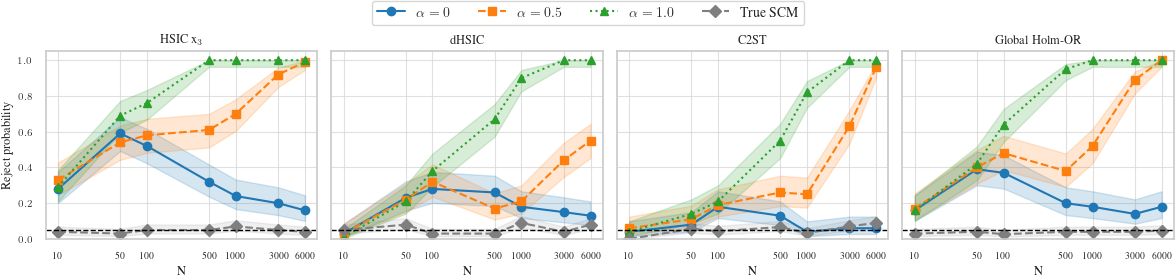

In [17]:
uncalibrated_diagnostic_map = {
    "reject_hsic3": "HSIC x3",
    "reject_dhsic": "dHSIC",
    "reject_c2st": "C2ST",
    "reject_global": "Global Holm-OR",
}
missing_cols = [col for col in uncalibrated_diagnostic_map if col not in df.columns]
if missing_cols:
    raise ValueError(
        "Missing uncalibrated rejection columns in diagnostic_power_results.csv: "
        f"{missing_cols}."
    )
uncalibrated_reject_long = df.melt(
    id_vars=["model_name", "alpha", "n", "seed"],
    value_vars=list(uncalibrated_diagnostic_map.keys()),
    var_name="diagnostic_key",
    value_name="reject",
)
uncalibrated_reject_long["diagnostic"] = uncalibrated_reject_long["diagnostic_key"].map(
    uncalibrated_diagnostic_map
)
uncalibrated_reject_long["model_label"] = uncalibrated_reject_long["model_name"].map(model_label_map)
uncalibrated_rows = []
for (model_name, model_label, alpha_value, n_value, diagnostic), group in uncalibrated_reject_long.groupby(
    ["model_name", "model_label", "alpha", "n", "diagnostic"], dropna=False
):
    successes = int(group["reject"].sum())
    total = int(group["reject"].count())
    wilson_low, wilson_high = wilson_interval(successes, total)
    uncalibrated_rows.append(
        {
            "model_name": model_name,
            "model_label": model_label,
            "alpha": float(alpha_value),
            "alpha_label": alpha_label_map[float(alpha_value)],
            "n": int(n_value),
            "diagnostic": diagnostic,
            "num_runs": total,
            "rejection_probability": successes / total if total > 0 else np.nan,
            "wilson_low": wilson_low,
            "wilson_high": wilson_high,
        }
    )
uncalibrated_reject_summary_df = (
    pd.DataFrame(uncalibrated_rows)
    .sort_values(["model_name", "diagnostic", "alpha", "n"])
    .reset_index(drop=True)
)
kan_uncalibrated_summary = uncalibrated_reject_summary_df[
    uncalibrated_reject_summary_df["model_label"] == "KAN"
].copy()
# Aggregate Oracle across alpha values to get a single True SCM reference per (diagnostic, n).
true_scm_rows = []
true_scm_long = uncalibrated_reject_long[
    uncalibrated_reject_long["model_label"] == "Oracle SCM"
].copy()
for (n_value, diagnostic), group in true_scm_long.groupby(["n", "diagnostic"], dropna=False):
    successes = int(group["reject"].sum())
    total = int(group["reject"].count())
    wilson_low, wilson_high = wilson_interval(successes, total)
    true_scm_rows.append(
        {
            "n": int(n_value),
            "diagnostic": diagnostic,
            "rejection_probability": successes / total if total > 0 else np.nan,
            "wilson_low": wilson_low,
            "wilson_high": wilson_high,
        }
    )
true_scm_df = pd.DataFrame(true_scm_rows).sort_values(["diagnostic", "n"]).reset_index(drop=True)
sns.set_theme(style="whitegrid")
with plt.rc_context({**bundles.neurips2024(nrows=1, ncols=4)}):
    fig, axes = plt.subplots(1, 4, figsize=(12, 2.7), sharex=True, sharey=True)
    fig.patch.set_facecolor("white")
    for col_index, diagnostic in enumerate(diagnostic_order):
        ax = axes[col_index]
        ax.set_facecolor("white")
        kan_subset = kan_uncalibrated_summary[
            kan_uncalibrated_summary["diagnostic"] == diagnostic
        ]
        for alpha_value in alpha_order:
            alpha_subset = kan_subset[kan_subset["alpha"] == alpha_value].sort_values("n")
            if alpha_subset.empty:
                continue
            ax.plot(
                alpha_subset["n"],
                alpha_subset["rejection_probability"],
                marker=marker_map[alpha_value],
                linestyle=line_style_map[alpha_value],
                color=palette[alpha_value],
                label=f"{alpha_label_map[alpha_value]}",
            )
            ax.fill_between(
                alpha_subset["n"],
                alpha_subset["wilson_low"],
                alpha_subset["wilson_high"],
                color=palette[alpha_value],
                alpha=0.18,
            )
        true_scm_subset = true_scm_df[
            true_scm_df["diagnostic"] == diagnostic
        ].sort_values("n")
        if not true_scm_subset.empty:
            ax.plot(
                true_scm_subset["n"],
                true_scm_subset["rejection_probability"],
                marker="D",
                linestyle="--",
                color=oracle_color,
                label="True SCM",
            )
            ax.fill_between(
                true_scm_subset["n"],
                true_scm_subset["wilson_low"],
                true_scm_subset["wilson_high"],
                color=oracle_color,
                alpha=0.12,
            )
        ax.axhline(0.05, color="black", linestyle="--", linewidth=1)
        ax.set_xscale("log")
        ax.set_xticks(n_ticks)
        ax.set_xticklabels([str(value) for value in n_ticks])
        ax.set_ylim(0.0, 1.05)
        ax.set_xlabel("N")
        ax.set_title(diagnostic)
        ax.grid(True, which="major", axis="both", color="#d9d9d9", linewidth=0.8, alpha=0.8)
        if col_index == 0:
            ax.set_ylabel("Reject probability")
    axes[0].set_title('HSIC x$_3$')
    handles, labels = [], []
    for axis in axes.flat:
        h, l = axis.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    by_label = dict(zip(labels, handles))
    fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.10),
        ncol=4,
        frameon=True,
        fontsize=10
    )
    plt.tight_layout()
    plt.savefig(paths.figures / "diagnostic_power_uncalibrated_kan_vs_oracle.pdf", dpi=300, bbox_inches="tight", facecolor="white")
    plt.savefig(paths.figures / "diagnostic_power_uncalibrated_kan_vs_oracle.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
##%%
